In [16]:
from IPython.display import HTML

HTML("""
<style>

a[href^="http://"],
a[href^="https://"] {
    color: blue !important;
}

/* stil za sve tabele */
table {
    margin-left: auto !important;
    margin-right: auto !important;
    width: auto !important;
    max-width: none !important;
    table-layout: auto !important;
    border-collapse: collapse !important;
    font-family: "Segoe UI", "Calibri", sans-serif !important;
    font-size: 12px !important;
}

th, td {
    padding: 8px 20px !important;
}

/* markdown tabela – zadrži staro ponašanje */
table:not(.dataframe) tr:first-child th {
    border-bottom: 2px solid #222 !important;
}

/* dataframe – samo pravo zaglavlje */
table.dataframe thead tr:first-child th {
    border-bottom: 2px solid #222 !important;
}

/* index kolona dataframe da ne bude bold */
table.dataframe tbody th {
    font-weight: normal !important;
}

/* linija ispod poslednjeg reda */
tbody tr:last-child td,
tbody tr:last-child th {
    border-bottom: 1px solid #aaa !important;
}

</style>
""")

# Uvod u analizu podataka - 🐼 Pandas
<br>

Cilj ovog poglavlja je
- Da se studenti upoznaju sa procesom pripreme podataka: učitavanje dataset-a, pregled strukture, čišćenje i formiranje novog DataFrame-a spremnog za analizu.
- Uvesti pivot tabele kao alat za sumiranje i restrukturiranje pripremljenih podataka.
- Povezati pivot tabele sa konceptom `GroupBy` i principom Split–Apply–Combine u analizi podataka.

Posle časa student treba da bude sposoban da:

- Samostalno pripremi podatke za pivot analizu — da učita dataset, doda kolone, spoji Series objekte i kreira konzistentan DataFrame.
- Primenjuje `pivot_table()` na realnim skupovima podataka uz pravilno definisanje `index`, `columns`, `values` i `aggfunc`.
- Na osnovu pivot analize interpretira rezultate u realnom kontekstu (npr. razlike po polu, klasi, godini, gradu…).

## Uvod 

U stvarnom svetu, podaci retko dolaze u savršenom obliku. Najčešće dobijamo CSV datoteke sa pogrešnim zaglavljima, eksel tabele sa viškom praznina, API odgovore sa nepotrebnim poljima ili čitave tekstualne datoteke iz kojih treba izdvojiti informacije. Tu nastupa Pandas — moćna Pajtonova biblioteka koja omogućava praktično sve korake tipične data-analitike:

- učitavanje podataka,
- pregled i razumevanje strukture,
- filtriranje, sortiranje i selektovanje,
- transformaciju i čišćenje,
- agregaciju i grupisanje,
- pripremu za vizuelizaciju i modeliranje.

Možete ga zamisliti i kao eksel, ali sa daleko više fleksibilnosti i automatizacije, koja omogućava da se i ogromni skupovi podataka analiziraju brzo i efikasno.

Ključni pojmovi u Pandasu su:

- `Series` – jednodimenzionalni niz podataka (kao kolona u tabeli),
- `DataFrame` – dvodimenzionalna tabela slična Excel-u, ali mnogo moćnija.


Pandas je danas standard u nauci o podacima, finansijskoj analizi, poslovnoj inteligenciji, ekonomiji, bankarstvu, statistici i istraživačkom radu. Gde god postoje podaci, verovatno je negde u blizini — Pandas.

Pandas nije samo biblioteka za manipulaciju podacima — on je interfejs za dijalog sa podacima, gde možemo odmah da dobijemo odgovor na konkretno pitanje koje se pojavljuje u tekstu. U nastavku ćemo baš to raditi: učitavaćemo podatke i na svako pitanje odgovaraćemo brzo, precizno i programski, koristeći Pandas kao najprirodniji način da ispitamo skup podataka.

Delovi ovog poglavlja zasnivaju se na konceptima i primerima predstavljenim u sledećim izvorima {cite}`mckinney2017,vanderplas2016,pandas_user_guide, kaggle_titanic, us_births_dataset`, uz dodatna objašnjenja i ilustracije prilagođene ekonomskim primenama.

## Instalacija Pandas-a

Ako koristite Anacondu, onda već imate instaliran modul Pandas. Ako je Pandas instaliran, možete da ga uvezete i proverite verziju:

In [2]:
import pandas
pandas.__version__

'2.3.3'

Ako nemate najnoviju verziju, tada modulom `pip` možemo ažuirati biblioteku sa:

In [ ]:
%pip install --upgrade pandas

Instalacija Pandas-a na vašem sistemu zahteva da se instalira NumPy-a. Pa ako nemate instaliranu Anacondu,  a već ste instalirali Numpy, tada prvo moramo da uvezemo pandas iz spoljnih izvora pip modulom:

In [ ]:
%pip install pandas

Kao što numpy obično uvozimo sa aliasom np, tako i pandas uvozimo sa aliasom pd:
```python
import pandas as pd
```

## Uvod u Pandas objekte

In [7]:
import numpy as np
import pandas as pd

### Objekat Series

Pandas objekat `Series` je jednodimenzionalni niz indeksiranih podataka. On se može kreirati iz liste ili ndarray objekta kao što sledi: 

In [8]:
podaci = pd.Series([0.12, 0.15, 0.17, 1.1, 1.2])
podaci

0    0.12
1    0.15
2    0.17
3    1.10
4    1.20
dtype: float64

Ako drugačije nije navedeno objekat Series je indeksiran poput jednodimenzionalne liste, torke ili ndarray objekta: celim uzastopnim brojevima koji počinju od nule. I ne samo to, pristup vrednostima Series objekta, isecanje, izmena i dodavanje je isto kao u rečnicima iili ndarray objektima. Primeri:

In [9]:
podaci[2]

np.float64(0.17)

In [10]:
podaci[5]=1.11
podaci

0    0.12
1    0.15
2    0.17
3    1.10
4    1.20
5    1.11
dtype: float64

Princip indeksiranja se može promeniti dodavanjemo argumenta `index` konstruktoru pd.Series čija je vrednost lista sa vrednostima indeksa. Interesatno je da lista sa indeksima može biti neuređena i da ima više istih vrednosti, što omogućava dodatne mogućnosti pri analizi podataka.

In [11]:
podaci = pd.Series([0.12, 0.15, 0.17, 1.1, 1.2], index = [1 , 3, 'a', 2.2, 0])
podaci

1      0.12
3      0.15
a      0.17
2.2    1.10
0      1.20
dtype: float64

Analogija serije kao rečnika može biti još jasnija konstruisanjem objekta serije direktno iz Python rečnika:

In [12]:
pop_dict = {    'Beograd': 1612085, 
                'Novi Sad': 372999,
                'Niš': 257867,
                'Kragujevac': 191919,
                'Leskovac': 144206, 
                'Subotica': 141554}
pop  = pd.Series(pop_dict)
pop

Beograd       1612085
Novi Sad       372999
Niš            257867
Kragujevac     191919
Leskovac       144206
Subotica       141554
dtype: int64

### Pandin objekat DataFrame

Možda najvažnija struktura u Pandasu je `DataFrame`. Kao i objekat Series, DataFrame možemo shvatiti kao generalizaciju Numpy ndarray objekta ili kao specijalizovani Python-ov rečnik.

#### Kreiranja DataFrame objekta

Objekat DataFrame možemo kreirati na veliki broj načina, ovde izdvajamo nekoliko. Kompletnu listu načina kreiranja objekta DataFrame sa svim detaljima možete naći na veb lokaciji:  https://pandas.pydata.org/docs/user_guide/io.html

**Kreiranje DataFrame objekta podacima iz datoteke.**<br/>
Objekat `DataFrame` možemo da kreiramo uvozom podataka iz datoteke. Evo dva primera sa *csv* i *xlsx* datotekama:

In [14]:
df = pd.read_csv("https://raw.githubusercontent.com/dazdejkovic/Podaci/main/OI/Pandas/vreme.csv", header=[0,1], index_col=[0,1], parse_dates=[1])
df.index.set_names(["Grad", "Datum"], inplace=True)
df.head(5)

Dan                                     \
                              Vreme Vetrovitost Maksimalna_temperatura   
Grad     Datum                                                           
Kembridz 2019-07-01           Kisno   SW 16 mph                     24   
         2019-07-02  Jaki pljuskovi    E 20 mph                     21   
         2019-07-03  Jaki pljuskovi   SE 10 mph                     22   
         2019-07-04           Kisno    S 25 mph                     22   
London   2019-07-01           Kisno   SW 16 mph                     28   

                                    Noc                                     
                                  Vreme Vetrovitost Maksimalna_temperatura  
Grad     Datum                                                              
Kembridz 2019-07-01               Kisno   SW 16 mph                     17  
         2019-07-02      Jaki pljuskovi    E 20 mph                     16  
         2019-07-03      Jaki pljuskovi   SE 10 mph                     16  
         2019-07-04  Mestimicno oblacno    S 25 mph                     16  
London   2019-07-01               Kisno   SW 16 mph                     18

ili

In [37]:
df=pd.read_excel("https://raw.githubusercontent.com/dazdejkovic/Podaci/main/OI/Pandas/vreme.xlsx", header=[0,1], index_col=[0,1], parse_dates=[1])
df.head(5)

Dan                                     \
                              Vreme Vetrovitost Maksimalna_temperatura   
Grad     Datum                                                           
Kembridz 2019-07-01           Kisno   SW 16 mph                     24   
         2019-07-02  Jaki pljuskovi    E 20 mph                     21   
         2019-07-03  Jaki pljuskovi   SE 10 mph                     22   
         2019-07-04           Kisno    S 25 mph                     22   
London   2019-07-01           Kisno   SW 16 mph                     28   

                                    Noc                                     
                                  Vreme Vetrovitost Maksimalna_temperatura  
Grad     Datum                                                              
Kembridz 2019-07-01               Kisno   SW 16 mph                     17  
         2019-07-02      Jaki pljuskovi    E 20 mph                     16  
         2019-07-03      Jaki pljuskovi   SE 10 mph                     16  
         2019-07-04  Mestimicno oblacno    S 25 mph                     16  
London   2019-07-01               Kisno   SW 16 mph                     18

Ako se datoteka ne nalazi u radnom direktorijumu onda navodimo apsolutnu  putanju do nje ili relativnu ako je folder koji je sadrži podfolder radnog. Takođe, moguće je navesti i lokaciju na mreži koja sadrži date podatke.

In [13]:
#Neophodno je imati najnoviju verziju Pandas-a
df= pd.read_excel("http://one.ekof.bg.ac.rs/~azdr/Data/OI/vreme.xlsx") 
df

,Datum,Temperatura,Brzina vetra,Događaj
0,2022-01-12,6,6,Kiša
1,2022-02-12,5,2,Sunce
2,2022-03-12,-2,1,Sneg


Kao što vidimo, vrste su na prirodan način indeksirane, međutim ako želimo da budu indeksirane nekom od kolona to se postiže dodavanjem argumeta *index_col* DataFrame konstruktoru:

In [14]:
df= pd.read_excel("http://one.ekof.bg.ac.rs/~azdr/Data/OI/vreme.xlsx", index_col ='Datum') 
df

,Temperatura,Brzina vetra,Događaj
Datum,,,
2022-01-12,6,6,Kiša
2022-02-12,5,2,Sunce
2022-03-12,-2,1,Sneg


**Konstrukcija DataFrame objekta pomoću rečnika listi.** <br/> 
Konstruktor `DataFrame`  će ključeve rečnika dodeliti imenima kolona, a vrednosti u kolonama će biti su u listi pod tim ključem.

In [14]:
recnik = { 'Datum' : ['2022-01-12', '2022-02-12', '2022-03-12'],
           'Temperatura' : [6, 5, -2],
           'Brzina vetra' : [6, 2, 1],
           'Događaj' : ['Kiša', 'Sunce', 'Sneg']}
df=pd.DataFrame(recnik)
df   

,Datum,Temperatura,Brzina vetra,Događaj
0,2022-01-12,6,6,Kiša
1,2022-02-12,5,2,Sunce
2,2022-03-12,-2,1,Sneg


Ako želimo da objekat bude indeksiran nekom od kolona, to postižemo na sledeći način:

In [15]:
df.set_index('Datum')

,Temperatura,Brzina vetra,Događaj
Datum,,,
2022-01-12,6,6,Kiša
2022-02-12,5,2,Sunce
2022-03-12,-2,1,Sneg


In [16]:
df

,Datum,Temperatura,Brzina vetra,Događaj
0,2022-01-12,6,6,Kiša
1,2022-02-12,5,2,Sunce
2,2022-03-12,-2,1,Sneg


Ako želimo trajnu izmenu koristimo argument *inplace* i njegovu vrednost `True`

In [17]:
df.set_index('Datum', inplace=True)
df

,Temperatura,Brzina vetra,Događaj
Datum,,,
2022-01-12,6,6,Kiša
2022-02-12,5,2,Sunce
2022-03-12,-2,1,Sneg


**Kreiranje DataFrame objekta pomoću listi sa torkama.**<br/>
U ovom slučaju svaka torka je jedan red DataFrame objekta. Konstruktor `pd.DataFrame` će dodeliti sam imena kolonama.

In [5]:
vreme = [
    ('2023-01-12', 6, 6, 'Kiša'),
    ('2023-02-12', 5, 2, 'Sunce'),
    ('2023-03-12', -2, 1, 'Sneg'),
    ('2023-26-12', 12, 3, 'Sunce'),
    ('2023-27-12', 11, 2, 'Sunce')]
df = pd.DataFrame(vreme)
df

,0,1,2,3
0,2023-01-12,6,6,Kiša
1,2023-02-12,5,2,Sunce
2,2023-03-12,-2,1,Sneg
3,2023-26-12,12,3,Sunce
4,2023-27-12,11,2,Sunce


Kao bi imenovali kolone, konstruktoru prosleđujemo dodavanjemo argument `columns` čija je vrednost  lista imena:

In [6]:
df = pd.DataFrame(vreme, columns=['Datum', 'Temperatura', 'Brzina vetra', 'Događaj'])
df

,Datum,Temperatura,Brzina vetra,Događaj
0,2023-01-12,6,6,Kiša
1,2023-02-12,5,2,Sunce
2,2023-03-12,-2,1,Sneg
3,2023-26-12,12,3,Sunce
4,2023-27-12,11,2,Sunce


**Kreiranje DataFrame objekta pomoću listi sa rečnicima.**<br/>
Lista čiji su elementi rečnici sa istim ključevima takođe može biti izvor za kreiranje DataFrame objekta. Prirodno, ključevi listi će biti imena kolona u DataFrame objektu.

In [20]:
vreme = [
    {'Datum':'2022-01-12', 'Temperatura': 6, 'Brzina vetra': 6, 'Događaj': 'Kiša'},
    {'Datum':'2022-02-12', 'Temperatura': 5, 'Brzina vetra': 2, 'Događaj': 'Sunce'},
    {'Datum':'2022-03-12', 'Temperatura': -2, 'Brzina vetra': 1, 'Događaj': 'Sneg'}]
df = pd.DataFrame(vreme)
df

,Datum,Temperatura,Brzina vetra,Događaj
0,2022-01-12,6,6,Kiša
1,2022-02-12,5,2,Sunce
2,2022-03-12,-2,1,Sneg


Čak i kad neki ključevi u rečniku nedostaju, Pandas će ih dopuniti sa `NaN` (tj. "nije broj") vrednostima:

In [21]:
pd.DataFrame([{'a':1, 'b':2}, {'a':3, 'c':4}])

,a,b,c
0,1,2.0,NaN
1,3,NaN,4.0


**Od jednog `Series` objekta.** </br>
Neki `DataFrame` je kolekcija `Series` objekata, a `DataFrame` sa jednom kolonom može se konstruisati od jednog `Series` objekta:

In [22]:
pd.DataFrame(pop, columns=['Populacija'])

,Populacija
Beograd,1612085
Novi Sad,372999
Niš,257867
Kragujevac,191919
Leskovac,144206
Subotica,141554


**Od rečnika sa objektima `Series`.**</br> 
`DataFrame` može se konstruisati pomoću rečnika čije su vrednosti objekati klase `Series`. Indeks novog objekta će sadžati uniju indeksa objekata Series.

In [23]:
area_dict = {   'Beograd': 1312, 
                'Novi Sad': 699,
                'Niš': 602,
                'Kragujevac': 826,
                'Leskovac': 1025, 
                'Subotica': 1008,
                'Valjevo': 2002}
area  = pd.Series(area_dict)
area

Beograd       1312
Novi Sad       699
Niš            602
Kragujevac     826
Leskovac      1025
Subotica      1008
Valjevo       2002
dtype: int64

In [24]:
df = pd.DataFrame({'Populacija':pop, 'Površina':area})
df

,Populacija,Površina
Beograd,1612085.0,1312
Kragujevac,191919.0,826
Leskovac,144206.0,1025
Niš,257867.0,602
Novi Sad,372999.0,699
Subotica,141554.0,1008
Valjevo,NaN,2002


**Od dvodimenzionalnog NumPy niza.**</br> 
Dati dvodimenzionalni niz podataka, može se konvertovati u `DataFrame` sa proizvoljnom specifikacijom imena za kolone i indeks. Ako se nešto od prethodnog izostavi, primeniće se celobrojni indeksi.

In [25]:
arr = np.random.randint(0,9, (3,2))
arr

array([[6, 2],
       [4, 1],
       [6, 3]])

In [26]:
df= pd.DataFrame(arr, columns=['A', 'B'], index=['x','y', 'z'])
df

,A,B
x,6,2
y,4,1
z,6,3


## Indeksiranje i selekcija podataka

U modulu NumPy videli smo detaljno metode i alate za pristup, postavljanje i menjanje vrednosti u ndarray objektima. To uključuje indeksiranje (`arr[2,3]`), izdvajanje (`arr[:,2:4]`), maskiranje (`arr[arr!=0]`), fensi indeksiranje (`arr[0,[2,7]]`) ili njihova kombinacija (`arr[:,[2,8]]`). Ovde ćemo videti slične ishode pri pristupu i modifikaciji vrednostima u Pandas objektima `Series` i `DataFrame`.

### Selekcija podataka u objektu `Series`

Kao što smo videli u prethodnom odeljku, objekat serije deluje na mnogo načina kao jednodimenzionalni NumPy niz, i na mnogo načina kao standardni Python rečnik. Ako imamo na umu ove dve analogije koje se preklapaju, to će nam pomoći da razumemo obrasce indeksiranja i selekcije podataka u ovim nizovima.

**Serija kao rečnik** 

Kao rečnik, objekat serije obezbeđuje mapiranje iz kolekcije ključeva u kolekciju vrednosti:

In [27]:
data = pd.Series(np.linspace(0,1,5), index = ['a', 'b', 'c', 'd', 'e'])
data

a    0.00
b    0.25
c    0.50
d    0.75
e    1.00
dtype: float64

In [28]:
data['d']

0.75

Takođe možemo da koristimo Python izraze i metode slične rečniku da bismo ispitali ključ/indeks i vrednosti:

In [29]:
'b' in data

True

In [30]:
data.keys()

Index(['a', 'b', 'c', 'd', 'e'], dtype='object')

In [31]:
list(data.items())

[('a', 0.0), ('b', 0.25), ('c', 0.5), ('d', 0.75), ('e', 1.0)]

Objekti serije mogu se čak modifikovati pomoću sintakse slične rečniku. Baš kao što možemo da proširimo rečnik dodeljivanjem novom ključu, možemo proširiti seriju dodeljivanjem na novu vrednost indeksa:

In [32]:
data['f']=1.25
data

a    0.00
b    0.25
c    0.50
d    0.75
e    1.00
f    1.25
dtype: float64

Ova laka promenljivost objekata je zgodna karakteristika: ispod haube Pandas donose odluke o rasporedu memorije i kopiranju podataka koje bi moglo biti potrebno; korisnik generalno ne mora da brine o ovim pitanjima.

**`Series` kao jednodimenzionalni niz**

Serija se zasniva na interfejsu nalik rečniku i omogućava selekciju u stilu niza preko istih osnovnih mehanizama kao i NumPy 
nizovima — to jest, isecanje, maskiranje i fensi indeksiranje. Primeri su sledeći:

In [33]:
# Izdvajanje eksplicitnim indeksom
data['d':'f']

d    0.75
e    1.00
f    1.25
dtype: float64

In [34]:
# Izdvajanje implicitnim celobrojnim indeksom
data[4:6]

e    1.00
f    1.25
dtype: float64

In [35]:
# Maskiranje
data[(data > 0.4) & (data < 1.1)]

c    0.50
d    0.75
e    1.00
dtype: float64

In [36]:
# Fensi indeksiranje
data[['b','f']]

b    0.25
f    1.25
dtype: float64

Među ovim operacijama, isecanje može biti izvor najveće zabune. Primetite to kada ste sekli sa eksplicitnim indeksom 
(tj. `data['d':'f']`), konačni indeks je *uključen* u isečak, dok kada sečete sa implicitnim indeksom (tj. `data[4:6]`), konačni indeks je *isključen* iz preseka.

**Indeksari: `loc, iloc`**

Ove konvencije sečenja i indeksiranja mogu biti izvor zabune. Na primer, ako vaša serija ima eksplicitni celobrojni indeks, operacija indeksiranja kao što je `data[1]` će koristiti eksplicitne indekse, dok će operacija sečenja kao što je `data[1:3]` koristiti implicitne indeks u Python stilu.

In [37]:
data = pd.Series(list('abcd'), index=range(1,9,2))
data

1    a
3    b
5    c
7    d
dtype: object

In [38]:
# eksplicitni index pri indeksiranju
data[3]

'b'

In [39]:
# implicitni index pri isecanju
data[1:3]

3    b
5    c
dtype: object

Zbog ove potencijalne zabune u slučaju celobrojnih indeksa, Pandas pruža posebne atribute indeksiranja koji eksplicitno otkrivaju određene šeme indeksiranja. Ovo nisu funkcionalne metode, već atributi koji izlažu određeni interfejs za sečenje
podataka u seriji.

Prvo, atribut `loc` dozvoljava indeksiranje i isesecanje koje uvek upućuje na eksplicitni indeks:

In [40]:
data.loc[3]

'b'

In [41]:
data.loc[1:3]

1    a
3    b
dtype: object

Atribut `iloc` omogućava indeksiranje i isecanje koje uvek upućuje na implicitni indeks u Python stilu:

In [42]:
data.iloc[3]

'd'

In [43]:
data.iloc[1:3]

3    b
5    c
dtype: object

Vodeći princip Python koda je da je „eksplicitno bolje od implicitnog“. Eksplicitna priroda `loc` i `iloc` ih čini veoma korisnim u održavanju čistog i čitljivog koda; posebno u slučaju celobrojnih indeksa, preporučujem da ih koristite kako bi
učinili kod lakšim za čitanje i razumevanje i sprečili suptilne greške zbog mešanja konvencija indeksiranja/isecanja.

### Selekcija podataka u `DataFrame`-u

Podsetimo se da DataFrame deluje na mnogo načina kao dvodimenzionalni ili strukturirani niz, ili na drugi način kao rečnik struktura serija koje dele isti indeks. Ove analogije mogu biti od pomoći dok istražujemo selekciju podataka unutar ove strukture.

**`DataFrame` kao rečnik**

Prva analogija koju ćemo razmotriti je `DataFrame` kao rečnik povezanih serija objekata. Vratimo se našem primeru područja i stanovništva gradova:

In [44]:
area = pd.Series({ 'Beograd': 1312, 'Novi Sad': 699, 'Niš': 602, 'Kragujevac': 826, 'Leskovac': 1025, 'Subotica': 1008})
pop  = pd.Series({ 'Beograd': 1612085, 'Novi Sad': 372999, 'Niš': 257867, 'Kragujevac': 191919, 'Leskovac': 144206, 
                   'Subotica': 141554})
data = pd.DataFrame({'Površina': area, 'Populacija':pop}) 
data

,Površina,Populacija
Beograd,1312,1612085
Novi Sad,699,372999
Niš,602,257867
Kragujevac,826,191919
Leskovac,1025,144206
Subotica,1008,141554


Može se pristupiti pojedinačnim serijama koje čine kolone DataFrame-a preko indeksiranja naziva kolone u stilu rečnika:

In [45]:
data["Površina"]

Beograd       1312
Novi Sad       699
Niš            602
Kragujevac     826
Leskovac      1025
Subotica      1008
Name: Površina, dtype: int64

Ekvivalentno, možemo koristiti pristup u stilu atributa sa nazivima kolona koji su stringovi:

In [46]:
data.Površina

Beograd       1312
Novi Sad       699
Niš            602
Kragujevac     826
Leskovac      1025
Subotica      1008
Name: Površina, dtype: int64

Ovaj pristup koloni u stilu atributa zapravo pristupa potpuno istom objektu kao i pristup u stilu rečnika:

In [47]:
data.Površina is data['Površina']

True

Kao i kod objekata serije o kojima smo ranije govorili, sintaksa u stilu rečnika takođe može biti od koristi za modifikaciju objekta, u ovom slučaju za dodavanje nove kolone:

In [48]:
data['gustina']=round(data['Populacija']/data['Površina'],0)
data

,Površina,Populacija,gustina
Beograd,1312,1612085,1229.0
Novi Sad,699,372999,534.0
Niš,602,257867,428.0
Kragujevac,826,191919,232.0
Leskovac,1025,144206,141.0
Subotica,1008,141554,140.0


Prethodna operacija, pokazuje jednostavnu sintaksu aritmetike element po element između objekata serije.

**`DataFrame` kao dvodimenzionalni niz**

Kao što je ranije pomenuto, DataFrame takođe možemo posmatrati kao poboljšani dvodimenzionalni niz. Možemo da koristimo osnovni niz podataka koristeći atribut `vrednost`:

In [49]:
data.values

array([[1.312000e+03, 1.612085e+06, 1.229000e+03],
       [6.990000e+02, 3.729990e+05, 5.340000e+02],
       [6.020000e+02, 2.578670e+05, 4.280000e+02],
       [8.260000e+02, 1.919190e+05, 2.320000e+02],
       [1.025000e+03, 1.442060e+05, 1.410000e+02],
       [1.008000e+03, 1.415540e+05, 1.400000e+02]])

Imajući na umu ovu sliku, možemo da uradimo mnoge poznate operacije na DataFrame-u, kao kod nizova. Na primer, možemo da transponujemo ceo DataFrame da zamenimo redove i kolone:

In [50]:
data.T

,Beograd,Novi Sad,Niš,Kragujevac,Leskovac,Subotica
Površina,1312.0,699.0,602.0,826.0,1025.0,1008.0
Populacija,1612085.0,372999.0,257867.0,191919.0,144206.0,141554.0
gustina,1229.0,534.0,428.0,232.0,141.0,140.0


Međutim, kada je reč o indeksiranju `DataFrame` objekata, jasno je nas indeksiranje kolona u stilu rečnika onemogućava da ga jednostavno tretiramo kao NumPy niz. Konkretno, prosleđivanjem jednog indeksa nizu pristupamo redu:

In [51]:
data.values[0]

array([1.312000e+03, 1.612085e+06, 1.229000e+03])

a prosleđivanjem jednog "indeksa" `DataFrame`-u  dobijamo kolonu!! :

In [52]:
data['Površina']

Beograd       1312
Novi Sad       699
Niš            602
Kragujevac     826
Leskovac      1025
Subotica      1008
Name: Površina, dtype: int64

Dakle, za indeksiranje u stilu niza, potrebna nam je još jedna konvencija. Ovde Pande ponovo koriste `loc` i `iloc` indeksare pomenute ranije. Koristeći `iloc` indekser, možemo indeksirati osnovni niz kao da je jednostavan NumPy niz (koristeći implicitni indeks u Python stilu), ali se indeks `DataFrame` i oznake kolona održavaju u rezultatu:

In [53]:
data.iloc[:3,:2]

,Površina,Populacija
Beograd,1312,1612085
Novi Sad,699,372999
Niš,602,257867


In [54]:
data.loc[:'Niš',:'Populacija']

,Površina,Populacija
Beograd,1312,1612085
Novi Sad,699,372999
Niš,602,257867


Bilo koji od poznatih obrazaca pristupa podacima u NumPy stilu može se koristiti u okviru ovih indeksatora. Na primer, u `loc` indeksatoru možemo kombinovati maskiranje i fensi indeksiranje, kao u sledećem primeru:

In [55]:
data.loc[data.gustina>400,['Populacija', 'gustina']]

,Populacija,gustina
Beograd,1612085,1229.0
Novi Sad,372999,534.0
Niš,257867,428.0


Bilo koja od ovih konvencija indeksiranja se takođe može koristiti za postavljanje ili modifikovanje vrednosti. To je
urađeno na standardni način na koji ste možda navikli kod NumPy:

In [56]:
data.iloc[0, 2] = 900
data

,Površina,Populacija,gustina
Beograd,1312,1612085,900.0
Novi Sad,699,372999,534.0
Niš,602,257867,428.0
Kragujevac,826,191919,232.0
Leskovac,1025,144206,141.0
Subotica,1008,141554,140.0


Da biste poboljšali svoju veštinu u manipulaciji Pandas podacima, predlažem da provedete malo vremena sa jednostavnim `DataFrame`-ovima, istraživanjem tipova indeksiranja, sečenja, maskiranja i fensi indeksiranje koje dozvoljavaju ovi različiti pristupi indeksiranju.

**Dodatne konvencije indeksiranja**

Postoji nekoliko dodatnih konvencija indeksiranja koje mogu izgledati u suprotnosti sa prethodnom diskusijom, ali ipak mogu biti veoma korisne u praksi. Prvo, *indeksiranje* odnosi se na kolone, a *isecanje* se odnosi na redove!!:

In [57]:
data['Novi Sad':'Leskovac']

,Površina,Populacija,gustina
Novi Sad,699,372999,534.0
Niš,602,257867,428.0
Kragujevac,826,191919,232.0
Leskovac,1025,144206,141.0


Ovakvo isecanje može takođe da referiše na redove prema broju umesto po indeksu:

In [58]:
data[1:5]

,Površina,Populacija,gustina
Novi Sad,699,372999,534.0
Niš,602,257867,428.0
Kragujevac,826,191919,232.0
Leskovac,1025,144206,141.0


Slično, direktne operacije maskiranja se takođe interpretiraju na redove umesto na kolone:

In [59]:
data[data.gustina <400]

,Površina,Populacija,gustina
Kragujevac,826,191919,232.0
Leskovac,1025,144206,141.0
Subotica,1008,141554,140.0


Ove dve konvencije su sintaksno slične onima na NumPy nizu, i mada se možda ne uklapaju tačno u šablon Pandas konvencija, ipak jesu prilično korisne u praksi.

## Operacije na podacima u Pandama

Jedan od osnovnih delova NumPy-a je sposobnost brzog izvođenja elemenat na element operacije, kako sa osnovnom aritmetikom (sabiranje, oduzimanje, množenje, itd.), tako i sa sofisticiranijim operacijama (trigonometrijske funkcije, eksponencijalne i logaritamske funkcije itd.). Pandas nasleđuje veliki deo ove funkcionalnosti od NumPy-a, a `ufuncs` koje smo uveli kod Numpy-ja su ključne u tome.

Pandas uključuje nekoliko korisnih zaokreta, međutim: za unarne operacije poput negacije i trigonometrijske funkcije, `ufunc` će sačuvati oznake indeksa i kolona na izlazu, a za binarne operacije kao što su sabiranje i množenje, Pandas će
automatski *poravnati indekse* prilikom prosleđivanja objekata ka `ufunc`. Takođe ćemo videti da postoje dobro definisane operacije između jednodimenzionalne strukture Serije i dvodimenzionalne strukture DataFrame.

### Univerzalne funkcije (`ufunc`): Očuvanje indeksa

Pošto je Pandas dizajniran da radi sa NumPy, bilo koja NumPy `ufunc` će raditi na Pandas objektima `Series` i `DataFrame`. Počnimo sa definisanjem jednostavne Serije i DataFrame na kome ćemo ovo demonstrirati:

In [60]:
np.random.seed(2021)
sr = pd.Series(np.random.randint(10,100,4))
sr

0    95
1    67
2    10
3    96
dtype: int32

In [61]:
df =pd.DataFrame(np.random.randint(10,100, (3,4)), 
                 columns = ['A', 'B', 'C', 'D'])
df

,A,B,C,D
0,54,72,39,31
1,34,22,80,80
2,43,17,11,36


Ako primenimo neku NumPy univerzalnu funkcije na bilo koji od ova dva objekta, rezultat će biti drugi Pandas objekat *sa sačuvanim indeksima*:

In [62]:
np.sin(sr)

0    0.683262
1   -0.855520
2   -0.544021
3    0.983588
dtype: float64

Ili, sa malo složenijem izračunavanjem:

In [63]:
round(np.cos(df*np.pi/2),2)

,A,B,C,D
0,-1.0,1.0,-0.0,-0.0
1,-1.0,-1.0,1.0,1.0
2,-0.0,-0.0,-0.0,1.0


Svaka od univerzalnih funkcija diskutovana u izračunavanjima na NumPy nizovima može se primeniti na sličan način.

### Univerzalne funkcije: Poravnavanje indeksa

Za binarne operacije na dva objekta Serije ili DataFrame, Pandas će poravnati indekse u procesu izvođenja operacije. Ovo je veoma zgodno kada se radi sa nepotpunim podacima, kao što ćemo videti u nekim od primera koji slede.

**Poravnavanje indeksa u Serijama**

Kao primer, pretpostavimo da kombinujemo dva različita izvora podataka, i pronašli samo samo tri grada u Srbiji najveća po *površini* i tri grada najveća po *broju stanovnika*:

In [64]:
area = pd.Series({ 'Beograd': 1312, 'Leskovac': 1025, 'Subotica': 1008})
pop  = pd.Series({ 'Beograd': 1612085, 'Novi Sad': 372999, 'Niš': 257867})

Pogledajmo šta će se desiti kada pokušamo da izračunamo gustinu naseljenosti:

In [65]:
pop/area

Beograd     1228.723323
Leskovac            NaN
Niš                 NaN
Novi Sad            NaN
Subotica            NaN
dtype: float64

Rezultujući niz sadrži *uniju* indeksa dva ulazna niza, koji možemo odrediti primenom standardne Python-ove skupovne aritmetike na ovim indeksima:

In [66]:
area.index.union(pop.index)

Index(['Beograd', 'Leskovac', 'Niš', 'Novi Sad', 'Subotica'], dtype='object')

Svaka stavka za koju jedno ili drugo nema unos je označeno sa `NaN`, ili „Nije broj“, tako Pande označava podatke koji nedostaju Ovo podudaranje indeksa je implementirano na ovaj način za bilo koju od Pithon-ovih ugrađenih aritmetičkih izraza; sve nedostajuće vrednosti podrazumevano se popunjavaju sa `NaN`:

In [67]:
A = pd.Series([1,2,3],index=[1,2,3])
B = pd.Series([1,2,3],index=[0,2,3])
A+B

0    NaN
1    NaN
2    4.0
3    6.0
dtype: float64

Ako korišćenje `NaN` vrednosti nije željeno ponašanje, možemo da izmenimo vrednost popunjavanja koristeći odgovarajuće objektne metode umesto operatora. Na primer, pozivanje `A.add(B)` je ekvivalentno pozivanju `A + B`, ali dozvoljava opcionu eksplicitnu specifikaciju vrednosti popunjavanja za sve elemente u `A` ili `B` koji možda nedostaju:

In [68]:
A.add(B, fill_value=0)

0    1.0
1    1.0
2    4.0
3    6.0
dtype: float64

**Poravnavanje indeksa u `DataFrame`-u**

Sličan tip poravnavanja ima mesto u kolonama i indeksima kad nameravamo da izvedemo operacije na `DataFrame`-ovima:

In [69]:
A = pd.DataFrame(np.random.randint(10,100, (2,2)), columns=['a', 'b'])
A

,a,b
0,76,58
1,73,59


In [70]:
B = pd.DataFrame(np.random.randint(10,100, (3,4)), columns=['b', 'c','a','d'])
B

,b,c,a,d
0,26,60,64,62
1,15,59,48,24
2,81,95,80,51


In [71]:
A+B

,a,b,c,d
0,140.0,84.0,NaN,NaN
1,121.0,74.0,NaN,NaN
2,NaN,NaN,NaN,NaN


Primetite da su indeksi ispravno poravnati, bez obzira na njihov redosled u dva objekta, a indeksi u rezultatu se sortiraju. Kao što je bio slučaj sa Serijom, možemo koristiti povezanu aritmetičku metodu objekta i prosledite bilo koju željenu vrednost `fill_value` koja će se koristiti na mestu nedostajućih unosa. Ovde ćemo popuniti srednju vrednost svih vrednosti u `A` (koju izračunavamo prvo slaganjem redova `A`):

In [72]:
fill = A.stack().mean()
A.add(B, fill_value = fill)

,a,b,c,d
0,140.0,84.0,126.5,128.5
1,121.0,74.0,125.5,90.5
2,146.5,147.5,161.5,117.5


:::{table} Lista Python operatora i ekvivalentnih Pandas metoda
:class: thin
:label: pandas_methods
:align: center
:header-rows: 1

|Pyhon Operator | Pandas metod(i)|
|:--------------|:---------------|
| `+`           | `add()` |
| `-`           | `sub(), substact()` |
| `*`           | `mul(), multiply()` |
| `/`           | `truediv(), div(), divide()`|
| `//`          | `floordiv()` |
| `%`           | `mod()` |
| `**`          | `pow()` |

:::

### Univerzalne funkcije: Operacija između `DataFrame` i `Series`

Kada izvodimo operacije između `DataFrame`-a i `Series`, indeks i poravnanje kolona se na sličan način održava. Operacije između `DataFrame`-a i `Series` su slične operacijama između dvodimenzionalnog i jednodimenzionalnog NumPy niza. Razmotrimo jednu uobičajenu operaciju, gde nalazimo razliku od dvodimenzionalnog niza i jednog od njegovih redova:

In [73]:
A = np.random.randint(10,100, (3,6))
A

array([[31, 35, 20, 46, 29, 67],
       [92, 25, 50, 86, 63, 21],
       [29, 43, 88, 27, 99, 60]])

In [74]:
A - A[0]

array([[  0,   0,   0,   0,   0,   0],
       [ 61, -10,  30,  40,  34, -46],
       [ -2,   8,  68, -19,  70,  -7]])

Prema pravilima emitovanja za nizove, oduzimanje dvodimenzionalnog niza i jednog od njegovih redova izvršava se po redovima.

U Pandasu, ova konvencija izvršava se na sličan način:

In [75]:
df = pd.DataFrame(A, columns=list("ABCDEF"))
df - df.iloc[0]

,A,B,C,D,E,F
0,0,0,0,0,0,0
1,61,-10,30,40,34,-46
2,-2,8,68,-19,70,-7


Ako hoćemo da imamo sličnu operaciju po kolonama, možemo da upotrebimo ranije spomenut metod objekta, specifikujući ključnu reč `axis`

In [76]:
df.subtract(df['C'], axis=0)

,A,B,C,D,E,F
0,11,15,0,26,9,47
1,42,-25,0,36,13,-29
2,-59,-45,0,-61,11,-28


Primetimo da ove operacije  između `DataFrame` i `Series`, kao i operacije o kojimo smo diskutovali ranije, automatski poravnavaju indekse među ova dva elementa:

In [77]:
polareda = df.iloc[0, ::2]
polareda

A    31
C    20
E    29
Name: 0, dtype: int32

### Sortiranje podataka u `DataFrame` objektu

Kreirajmo prvo neke podatke:

In [23]:
df= pd.DataFrame(np.random.randint(1,4,size=16).reshape(4,4), 
                 index = ['crvena', 'plava', 'zelena', 'bela'], 
                 columns=['Lopta','Olovka','Flomaster','Papir'])
df

,Lopta,Olovka,Flomaster,Papir
crvena,1,2,3,2
plava,3,1,3,3
zelena,3,1,3,1
bela,3,3,2,2


Za sortiranje podataka u Pandasu važe ista pravila kao i za sortiranje listi, podrazumeva se sortiranje u rastućem poretku i metod daje samo pogled na uređene podatke. Ovde međutim, imamo više mogućnosti. Za početak imamo metode koji sortiraju po  koloni ili kolonama i metode koje sortiraju po indeksu ili indeksima.

In [24]:
df.sort_values(by=['Olovka'], inplace=True)

In [25]:
df

,Lopta,Olovka,Flomaster,Papir
plava,3,1,3,3
zelena,3,1,3,1
crvena,1,2,3,2
bela,3,3,2,2


In [26]:
df.sort_index(ascending=False)

,Lopta,Olovka,Flomaster,Papir
zelena,3,1,3,1
plava,3,1,3,3
crvena,1,2,3,2
bela,3,3,2,2


Sortiranje može biti bazirano i na više kolona sa više kriterijuma

In [30]:
df.sort_values(by=['Olovka', 'Papir'],  ascending=[False, True])

,Lopta,Olovka,Flomaster,Papir
bela,3,3,2,2
crvena,1,2,3,2
zelena,3,1,3,1
plava,3,1,3,3


Kompletnu lista opcija se možemo uvek dobit magičnom komandom `df.sort_values?`

### Brisanje podataka u `DataFrame` objektu

Za uklanjanje ili brisanje podataka iz DataFrame ili Series objekata kosriste se metodi:
- `drop` uklanjanjanje jednog ili više redova ili kolona.
- `dropna` uklanjanjanje jednog ili više redova ili kolona koji sadrže vrednost `Nan`.

Metodi daju samo pogled na preostale podatke, ako hoćemo da promena bude trajna tada postavljamo da vrednost parametar `inplace=True`.

Konstrišimo prve neki DataFrame objekat:

In [5]:
df = pd.DataFrame({'Matematika': [60,89,82,70], 'Ekonomija': [66,95,83,66], 'Statistika': [61,91,77,70]}, 
                  index=['A', 'B', 'C', 'D'])
df

,Matematika,Ekonomija,Statistika
A,60,66,61
B,89,95,91
C,82,83,77
D,70,66,70


- Brisanje jednog reda

In [10]:
df.drop(df.index[0])

,Matematika,Ekonomija,Statistika
B,89,95,91
C,82,83,77
D,70,66,70


In [11]:
# To je ekvivalentno sa
df.drop('A')

,Matematika,Ekonomija,Statistika
B,89,95,91
C,82,83,77
D,70,66,70


- Brisanje više redova

In [13]:
df.drop(['A','C'])

,Matematika,Ekonomija,Statistika
B,89,95,91
D,70,66,70


In [15]:
df.drop(df.index[1:3])

,Matematika,Ekonomija,Statistika
A,60,66,61
D,70,66,70


In [16]:
# Brisanje poslednjeg reda
df.drop(index=df.index[-1])

,Matematika,Ekonomija,Statistika
A,60,66,61
B,89,95,91
C,82,83,77


- Brisanje kolona

In [19]:
# Brisanje cele kolone
df.drop(labels='Matematika', axis=1)

,Ekonomija,Statistika
A,66,61
B,95,91
C,83,77
D,66,70


In [20]:
# Ili još jasnije
df.drop(columns='Matematika')

,Ekonomija,Statistika
A,66,61
B,95,91
C,83,77
D,66,70


- Brisanje više kolona

In [21]:
df.drop(columns=['Matematika', 'Statistika'])

,Ekonomija
A,66
B,95
C,83
D,66


- Brisanje kolone bazirano na poziciji

In [28]:
df.drop(columns=df.columns[0:3:2]) #Brisanje svake druge kolone

,Ekonomija
A,66
B,95
C,83
D,66


<br>
<br>

## Vizuelizacija u modulu Pandas

Vizuelizacija u modulu Pandas baziranja je na sledeće dve činjenice:

- *Matlotlib modul može da prihvati kolone DataFrame-a kao ulazne podatke.*
- *Pandas ima svoje metode za vizelizaciju koje su kompatibilne sa metodama iz modula matplotlib*.

Rad počinjemo uvoženjem neophodnih modula i postavljanjem beležnice za statične dijagrame.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

```{admonition} Primer 1. 
:class: tip
Na veb adresi `https://raw.githubusercontent.com/KeithGalli/matplotlib_tutorial/master/gas_prices.csv` nalaze podaci o ceni gasa u USA i Kanadi 90 tih godina. Skicirajte linijski dijagram tih podataka.
```

Učitajmo podatke i pogledajmo prvih nekoliko redova:

In [19]:
gas = pd.read_csv('https://raw.githubusercontent.com/KeithGalli/matplotlib_tutorial/master/gas_prices.csv')
gas.head(3)

,Year,Australia,Canada,France,Germany,Italy,Japan,Mexico,South Korea,UK,USA
0,1990,NaN,1.87,3.63,2.65,4.59,3.16,1.0,2.05,2.82,1.16
1,1991,1.96,1.92,3.45,2.90,4.50,3.46,1.3,2.49,3.01,1.14
2,1992,1.89,1.73,3.56,3.27,4.53,3.58,1.5,2.65,3.06,1.13


Ako hoćemo da pratimo cenu gasa u Americi i Kanadi ...

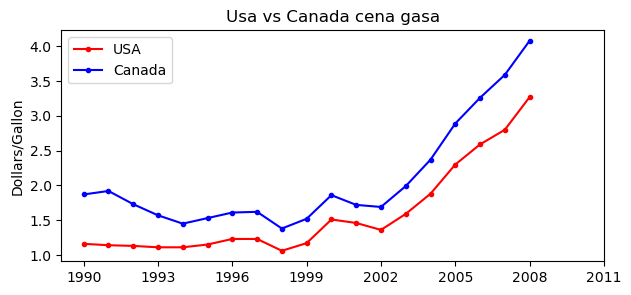

In [20]:
plt.figure('Linijski dijagram - Matlab stil, preko metoda plot iz matplotliba', figsize=(7,3))

plt.plot(gas.Year, gas.USA, 'r.-', label='USA')         # MatLab stil
plt.plot(gas.Year, gas.Canada, 'b.-', label='Canada')
plt.title('Usa vs Canada cena gasa')
plt.ylabel('Dollars/Gallon')
plt.legend()

plt.xticks(gas.Year[::3].tolist()+[2011])

plt.show()

Kakve zaključke bi mogli da izvedemo iz prethodnog dijagrama?

Primetite da smo sve vreme koristili biblioteku `matplotlib` za vizulelizaciju.

```{admonition} Primer 2. 
:class: tip
Podaci o FIFA igračima nalaze se na sledećoj adresi: `https://raw.githubusercontent.com/rashida048/Datasets/master/fifa.csv`. 

- Skicirajte histogram raspodele veštine svih igrača.
- Koristeći box-plot uporedite veštine Reala i Barselone.

Učitajmo prvo podatke i upoznajmo se sa njima:

In [4]:
fifa = pd.read_csv('https://raw.githubusercontent.com/rashida048/Datasets/master/fifa.csv')
fifa.head(2)

,Unnamed: 0,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
0,0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,27,1987-06-24,169,67,Argentina,...,76,NaN,25,21,20,6,11,15,14,8
1,1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,29,1985-02-05,185,80,Portugal,...,85,NaN,22,31,23,7,11,15,14,11


In [ ]:
fifa.columns
fifa.info

Baza podataka sadrži podatke o 16155 igrača i u svakom zapisu imamo 81 atribut

*Analiza raspodele veštine igrača:*

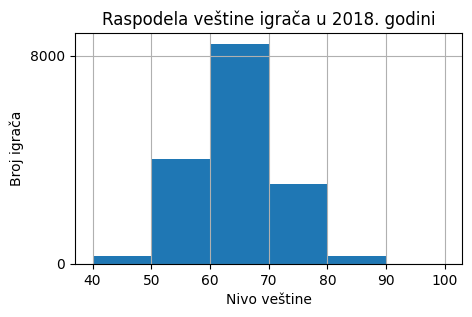

In [13]:
plt.figure(figsize=(5,3))
bins=[40,50,60,70,80,90,100]
fifa.overall.hist(bins=bins)     #Pandas metod hist
plt.xticks(bins)
plt.ylabel("Broj igrača")
plt.xlabel('Nivo veštine')
plt.title('Raspodela veštine igrača u 2018. godini')
plt.yticks([0,8000])
plt.show()

*Upoređivanje veštine fudbalera Barselone i Reala preko box-plota:*

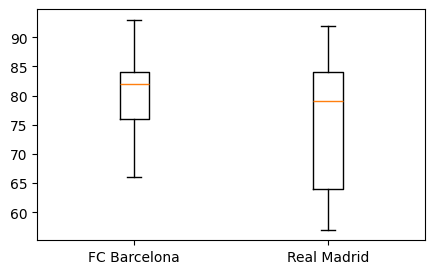

In [7]:
plt.figure('Box-plot - Matlab stil, poziv metoda boxplot matplotliba čiji su argumenti dva objekta klase Series', figsize=(5,3))

barcelona = fifa[fifa.club_name=='FC Barcelona']['overall']  #izdvajanje podataka o veštini fudbalera Barselone. Series objekat.
real = fifa[fifa.club_name=='Real Madrid']['overall']        #izdvajanje podataka o veštini fudbalera Real. Series objekat.

labels = ['FC Barcelona', 'Real Madrid']

plt.boxplot([barcelona, real], labels = labels)
plt.show()

Kakve bi zaključke mogli da izvedemo na osnovu poslednjeg dijagrama?

```{admonition} Primer 3. 
:class: tip
U datoteci `Podaci/Admission_Predict.csv` nalaze se podaci sa jednog prijemnog ispita. Koristeći metode biblioteke Pandas:

- Pozovite pandas metod `hist` za skiciranje histograma izabranih kolone kreiranog DataFrame objekta na osnovu datih podataka.
- Odredite korelaciju odgovarajućih kolona sa kolonom `Çhance of Admit`.
- Vizuelizujte podatke o korelaciji.

Učitajmo prvo podatke i upoznajmo se sa njima:

In [15]:
df_AP = pd.read_csv('Podaci/Admission_Predict.csv', index_col='Serial No.') #Kad prethodno vidimo da je prva kolona u stvari indeks
df_AP.head(3)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76
3,316,104,3,3.0,3.5,8.00,1,0.72


In [19]:
df_AP.columns

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA',
       'Research', 'Chance of Admit'],
      dtype='object')

Možemo da pozovemo pandas metod hist za izabrane kolone DataFrame objekta

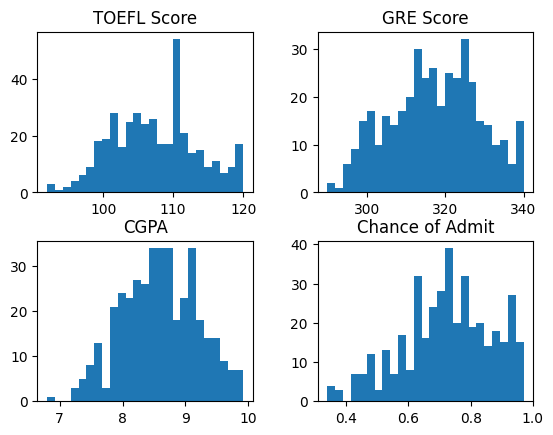

In [21]:
df_AP.hist( column=['TOEFL Score', 'GRE Score', 'CGPA', 'Chance of Admit'],bins=25, ls='dashed', grid=False);
# Primetite da sada koristimo Pandas metod hist za histograme !!

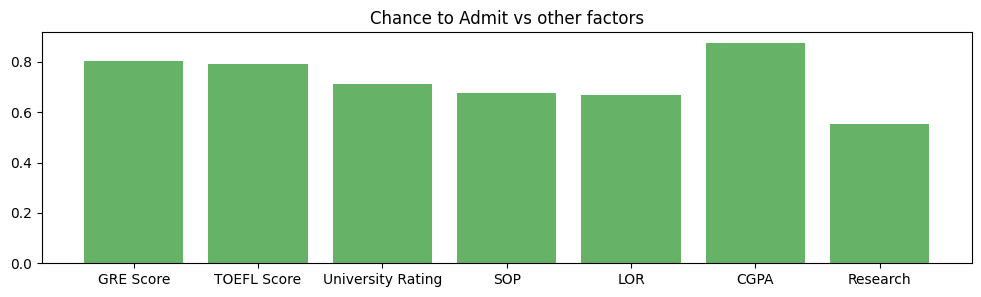

GRE Score            0.802610
TOEFL Score          0.791594
University Rating    0.711250
SOP                  0.675732
LOR                  0.669889
CGPA                 0.873289
Research             0.553202
dtype: float64


In [56]:
fig=plt.figure(figsize=(12,3))
col=['GRE Score', 'TOEFL Score', 'University Rating', 'SOP','LOR', 'CGPA', 'Research']
korelacija = df_AP[col].corrwith(df_AP['Chance of Admit'])
plt.bar(col, korelacija, color = 'green', alpha=0.6) #matplotlib.pyplot metod
plt.title("Chance to Admit vs other factors")
plt.show()
print(korelacija)

Da li nešto možete da zaklučite na osnovu voih dijagrama?

```{admonition} Primer 4.
:class: tip
Kreiranje stubičastih dijagrama.

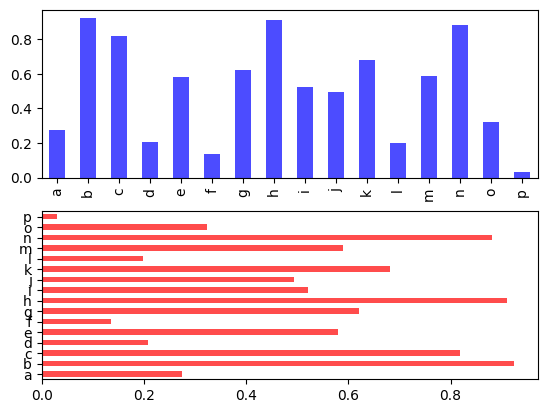

In [29]:
# Koristićemo objektno okruženje, koje funkcioniše samo u notebook režimu
fig, axes = plt.subplots(2,1)  # Objektno okruženje

# Kreiranje Serije
data=pd.Series(np.random.rand(16), index =list('abcdefghijklmnop'))

# Pandas metod plot.bar za vertikalni stubičasti dijagram
data.plot.bar(ax=axes[0], color ='b', alpha = 0.7)

# Pandas metod plot.barh za horizontalni stubičasti dijagram
data.plot.barh(ax=axes[1], color ='r', alpha = 0.7)
plt.show()

Kreiranje grupnih stubičastih dijagrama:

In [41]:
df1 = pd.DataFrame(np.random.rand(5,4),
                 index=['2008', '2012', '2016','2020', '2022'],
                 columns= pd.Index(['GB','USA','RUS','CHN'], name = 'State'))
df1.index.name = 'Godina'
df1

State,GB,USA,RUS,CHN
Godina,,,,
2008,0.962081,0.842515,0.667108,0.382030
2012,0.051649,0.688928,0.421227,0.108980
2016,0.061504,0.287646,0.899722,0.199015
2020,0.285862,0.081702,0.115641,0.077924
2022,0.393509,0.524838,0.129492,0.368705


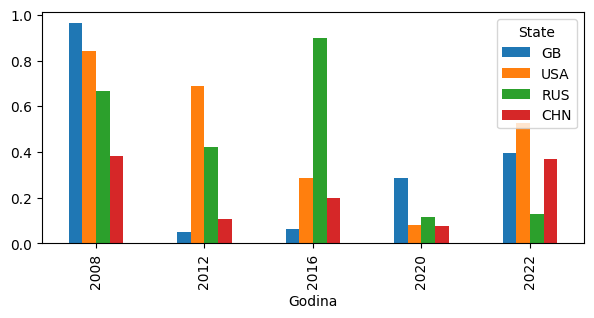

In [44]:
df1.plot.bar(figsize=(7,3))  #Pandas Metod
dfn = pd.Series(np.random.normal(size=100))  # Uzorak veličine 100 iz Standardne normalne raspodele

```{admonition} Primer 5.
:class: tip
Kreranje gustine raspodele.

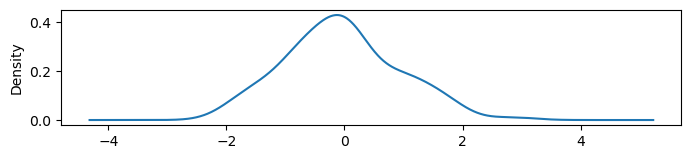

In [21]:
dfn = pd.Series(np.random.normal(size=100))  # Uzorak veličine 100 iz Standardne normalne raspodele
plt.figure(figsize=(8,1.5))
dfn.plot.density(); # Pandas metod za kreiranje histograma gustine       

I na kraju, jasno je da se sve opcije nemoguće zapamtiti, ali uvek možemo zatražiti pomoć preko:

In [ ]:
data.plot?

<br>
<br>

## Agregacija podataka i grupne operacije

U ovoj sekciji naučićete kako da: 
- agregirate podatke, primenite transformacije unutar grupe ili druge manipulacije, poput normalizacije, linearne regresije, ranga ili izbor podskupa.
- Konstruišete pivot tabele.

### GroupBy: Podeli, primeni, kombinuj  (Split, Apply, Combine)

Kada radimo sa većim skupovima podataka, često nas ne zanima samo svaki pojedinačni zapis — već želimo da vidimo ponašanje grupa podataka: prosečne vrednosti po mesecima, prodaju po kategorijama, ocene po razredima, temperature po danima itd. Tu dolazi `GroupBy`.

Pandas implementira veoma moćan koncept poznat kao Split–Apply–Combine:
- Split (Podeli) — podeli redove u grupe prema ključu (npr. grad, mesec, tip_proizvoda)
- Apply (Primeni) — izvrši operaciju nad svakom grupom posebno (mean(), sum(), count(), sopstvena funkcija…)
- Combine (Kombinuj) — spoji rezultate u jednu urednu tabelu

Na primer, ako imamo podatke o prodaji proizvoda, GroupBy nam omogućava da brzo i intuitivno odgovorimo na pitanja kao što su:
- Koja kategorija proizvoda ima najveći promet?
- Koliko je prosečno trajanje vožnje u svakoj Uber zoni?
- Koji je grad imao najvišu temperaturu?
- Koliko transakcija ima po korisniku?

GroupBy nije samo filter ili sortiranje — to je način da agregiramo informacije i otkrijemo obrasce koji nisu vidljivi iz pojedinačnih redova.

```{figure} Pandas_Slike/groupby.png
:width: 350px
:align: center

Ilustracija grupne agregacije
```

Iskoristimo sliku da pokažemo kako se princip praktično realizuje. Prvo učitajmo neophodne bibliteke i kreirajmo podatke:

In [1]:
import numpy as np
import pandas as pd

In [3]:
df = pd.DataFrame({'key': ['A', 'B', 'C', 'A', 'B', 'C'], 'data': range(1,7)}, columns=['key', 'data'])
df

,key,data
0,A,1
1,B,2
2,C,3
3,A,4
4,B,5
5,C,6


Možemo da izračunamo najosnovniju operaciju podeli-primeni-kombinuj pomoću `groupby()` metodom objekta `DataFrames`, prosleđujući ime željene ključne kolone:

In [5]:
df.groupby('key')

In [7]:
df.groupby('key').sum()

,data
key,
A,5
B,7
C,9


#### Objekat `GroupBy`

Objekat `GroupBy` je veoma fleksibilna apstrakcija. Na mnogo načina možete ga jednostavno tretirati kao kolekciju `DataFrame`-ova koja radi teške stvari ispod haube. Hajde da vidimo neke primere koristeći podatke iz košarke.

In [11]:
kosarka = pd.DataFrame({   'team': ['A', 'B', 'B', 'B', 'B', 'M', 'M', 'M'],
                           'position': ['G', 'G', 'F', 'G', 'F', 'F', 'C', 'C'],
                           'assists': [5, 7, 7, 8, 5, 7, 6, 9],
                           'rebounds': [11, 8, 10, 6, 6, 9, 6, 10]})
kosarka

,team,position,assists,rebounds
0,A,G,5,11
1,B,G,7,8
2,B,F,7,10
3,B,G,8,6
4,B,F,5,6
5,M,F,7,9
6,M,C,6,6
7,M,C,9,10


Najvažnije operacije koje nam `GroupBy` stavlja na raspolaganje su *agregacija, filtriranje, transformacija* i *primena*. O svakoj od njih ćemo detaljnije razgovarati kasnije, ali pre toga hajde da predstavimo neke druge funkcionalnosti koje se mogu koristiti sa osnovnom operacijom `GroupBy.`

**Indeksiranje kolone.** Objekat `GroupBy` podržava indeksiranje kolona na isti način kao `DataFrame` i vraća izmenjeni `GroupBy` objekat. Na primer:

In [13]:
kosarka.groupby('team')['assists'].median()

team
A    5.0
B    7.0
M    7.0
Name: assists, dtype: float64

Prethodno je moguće i ako izaberemo više kolona za grupisanje:

In [15]:
means = kosarka.groupby(['team', 'position'])['assists'].mean()
means

team  position
A     G           5.0
B     F           6.0
      G           7.5
M     C           7.5
      F           7.0
Name: assists, dtype: float64

**Iteracija preko grupa.** `Objekat GroupBy` možemo zamisliti kao rečnik DataFrame objekata čiji su ključevi različite vrednosti po kojima se vrši grupisanje, pa je stoga prirodno da podržava direktnu iteraciju preko grupa, vraćajući svaku grupu kao `Series` ili `DataFrame`:

In [17]:
for (team, grupa) in kosarka.groupby('team'):
    print(team)
    print(grupa)

A
  team position  assists  rebounds
0    A        G        5        11
B
  team position  assists  rebounds
1    B        G        7         8
2    B        F        7        10
3    B        G        8         6
4    B        F        5         6
M
  team position  assists  rebounds
5    M        F        7         9
6    M        C        6         6
7    M        C        9        10


Ovo može biti korisno za obavljanje određenih stvari "ručno".

**Metode otpreme.** Kroz neku magiju klase Pithon, bilo koji metod koji nije eksplicitno implementiran od strane `GroupBy` objekta biće prosleđen i pozvan grupama, bilo da su objekti `DataFrame` ili `Series.` Na primer, možete koristiti
`describe()` metodom objekta `DataFrame` za izvođenje skupa agregacija koje opisuju svaku od grupa u podacima:

In [19]:
kosarka.groupby('team')['assists'].describe()

,count,mean,std,min,25%,50%,75%,max
team,,,,,,,,
A,1.0,5.000000,NaN,5.0,5.0,5.0,5.00,5.0
B,4.0,6.750000,1.258306,5.0,6.5,7.0,7.25,8.0
M,3.0,7.333333,1.527525,6.0,6.5,7.0,8.00,9.0


#### Agregacija, filtriranje, transformacija i primena
Prethodna diskusija se fokusirala na operaciju agregacije, ali dostupno je više opcija. Konkretno, `GroupBy` objekti imaju `aggregate(), filter(), transform()` i `apply()` metode koje efikasno implementiraju različite korisne operacije pre kombinovanja grupisanih podataka.

Za potrebe sledećih pododeljaka, koristićemo sledeći `DataFrame`:

In [21]:
np.random.seed(2022)
df = pd.DataFrame({'key': ['A', 'B', 'C', 'A', 'B', 'C'],  
                   'data1': range(6), 
                   'data2': np.random.randint(10, 100, 6)},
                    columns = ['key', 'data1', 'data2'])
df

,key,data1,data2
0,A,0,55
1,B,1,59
2,C,2,65
3,A,3,98
4,B,4,28
5,C,5,34


**Agregacija.** Upoznali smo se sa `GroupBy` agregacijama `sum()`, `median()`, i slično, ali metoda `aggregate()` omogućava još veću fleksibilnost. Može uzeti listu agregata i izračunati sve agregate odjednom. Ovde je brz primer:

In [23]:
df.groupby('key').aggregate(['min', 'median', 'max'])

data1            data2           
      min median max   min median max
key                                  
A       0    1.5   3    55   76.5  98
B       1    2.5   4    28   43.5  59
C       2    3.5   5    34   49.5  65

Još jedan koristan obrazac je da se operacijama prosledi rečnik mapiranja imena kolona i primena na tu kolonu:

In [25]:
df.groupby('key').aggregate({'data1': 'min',
                             'data2': 'max'})

,data1,data2
key,,
A,0,98
B,1,59
C,2,65


**Filtriranje.** Operacija filtriranja vam omogućava da izostavite podatke na osnovu svojstava grupe. Na primer, možda bismo želeli da zadržimo sve grupe u kojima je standardna devijacija veća od neke kritične vrednosti:

In [27]:
def filter_func(x):
    return x['data2'].std() > 25

print(df)
print(df.groupby('key').std())
print(df.groupby('key').filter(filter_func))

  key  data1  data2
0   A      0     55
1   B      1     59
2   C      2     65
3   A      3     98
4   B      4     28
5   C      5     34
       data1      data2
key                    
A    2.12132  30.405592
B    2.12132  21.920310
C    2.12132  21.920310
  key  data1  data2
0   A      0     55
3   A      3     98


Funkcija `filter()` vraća Bulovu vrednost koja navodi da li grupa prolazi filtriranje. Ovde, zato što grupa A nema standardnu devijaciju veću od 25, izbacuje se iz rezultata.

**Transformacija.** Dok agregacija mora da vrati smanjenu verziju podataka, transformacija može da vrati neku transformisanu verziju punih podataka za rekombinovanje. Za takvu transformaciju, izlaz je istog oblika kao i ulaz. Uobičajen primer
je centriranje podataka oduzimanjem srednje vrednosti grupe:

In [29]:
df.groupby('key').transform(lambda x: x - x.mean())

,data1,data2
0,-1.5,-21.5
1,-1.5,15.5
2,-1.5,15.5
3,1.5,21.5
4,1.5,-15.5
5,1.5,-15.5


**Metod `apply().`** Metod `apply()` vam omogućava da primenite proizvoljnu funkciju na grupne rezultate. Funkcija treba da uzme `DataFrame` i da vrati ili Pandas objekat (npr. `DataFrame`, `Series`) ili skalar; tip vraćenog izlaza je prilagođen  operacijama koje treba izvesti.

Na primer, ovde je `apply()` normalizuje prvu kolonu zbirom vrednosti druge kolone:

In [35]:
def norm_by_data2(x):
    # x je DataFrame grupnih vrednosti
    x['data1'] /= x['data2'].sum()
    return x
print(df)
print(df.groupby('key', group_keys=True).apply(norm_by_data2))

  key  data1  data2
0   A      0     55
1   B      1     59
2   C      2     65
3   A      3     98
4   B      4     28
5   C      5     34
      key     data1  data2
key                       
A   0   A  0.000000     55
    3   A  0.019608     98
B   1   B  0.011494     59
    4   B  0.045977     28
C   2   C  0.020202     65
    5   C  0.050505     34


C:\Users\Dragan Azdejkovic\AppData\Local\Temp\ipykernel_5084\1197921029.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(df.groupby('key', group_keys=True).apply(norm_by_data2))


`apply()` unutar `GroupBy` je prilično fleksibilan: jedini kriterijum je da funkcija preuzima `DataFrame` i vraća Pandas objekat ili skalar; ono što radite u sredini je do vas!

<br>
<br>

### Pivot Tabele

Pivot tabele u Pandasu služe da sumarizuju i restrukturiraju podatke — idealne su kada imamo tabelu sa mnogo redova i želimo brzo da vidimo agregirane informacije po kategorijama. Veoma su brze i efikasne za velike podatke.

U matematičko-programerskom smislu pivot tabela primenjuje isti princip kao groupby: Split → Apply → Combine

```{admonition} Primer 1.
:class: tip

Baza podataka sa Titanika.

Učitajmo prvo neophodne bibliteke i podatke:

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns    # Modul za statističku analizu podataka. Sadrži različite skupove podataka za edukativne svrha
titanic = sns.load_dataset('titanic')
# titanic.to_csv('Pandas_Podaci/titanic.csv',index='') # Ako već imamo na disku
# titanic=pd.read_csv('Pandas_Podaci/titanic.csv') # Ako već imamo na disku


In [39]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Baza podataka sadrži obilje informacija o svakom putniku tog nesrećnog putovanja, uključujući pol, godine, klasu, plaćenu kartu i još mnogo toga.

#### Ručna pravljena pivot tabela

In [41]:
titanic.groupby('sex')[['survived']].mean()

,survived
sex,
female,0.742038
male,0.188908


Ovo nam odmah daje neki uvid: sveukupno, tri od svake četiri žene na brodu su preživele, dok je samo jedan od pet muškaraca preživeo!

Ovo je korisno, ali možda bismo želeli da odemo korak dublje i pogledamo preživljavanje oba pola i, recimo, razred. Koristeći jezik `GroupBy`, mogli bismo da nastavimo da koristimo nešto ovako: *grupišemo* po klasi i polu, *biramo* preživljavanje, *primenjujemo* *agregat* srednjih vrednosti, *kombinujemo* rezultujuće grupe, a zatim razložimo hijerarhijski indeks da bismo otkrili skrivenu višedimenzionalnost. U kodu:

In [47]:
titanic.groupby(['sex', 'class'],observed=True)['survived'].aggregate('mean').unstack() 
# parametar observed je povezan sa tipom podataka. Podrazumevana vrednost je False i referiše na numeričke podatke

class,First,Second,Third
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


Sad imamo bolju predstavu o tome kako su i rod i klasa u kojem se putovalo uticali na opstanak, ali kod počinje da izgleda pomalo glomazno. Iako svaki korak ovog koda ima smisla s obzirom na alate o kojima smo prethodno razgovarali, dugačak kod nije lako čitati ili koristiti. Ovaj dvodimenzionalni `GroupBy` je dovoljno uobičajen pa Pandas uključuje praktičnu rutinu, `pivot_table`, koja sažeto obrađuje ovu vrstu višedimenzionalne agregacije.

#### Sintaksa Pivot tabele

Evo ekvivalenta prethodnoj operaciji koja koristi metod `pivot_table` na objektu `DataFrame`:

In [51]:
titanic.pivot_table('survived', index='sex', columns='class',observed=False)

class,First,Second,Third
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


Ovo je izuzetno čitljivije od pristupa `GroupBy,` a proizvodi isti rezultat. Kao što možete očekivati od transatlantskog krstarenja ranog 20. veka, gradijent preživljavanja favorizuje i žene i putovanje u višoj klasi. Žene koje putuju u prvoj klasi preživele su skoro izvesno (zdravo, Rouz!), dok je samo jedan od deset muškaraca koji je putovao u trećoj klase preživeo (izvini, Džek!).

#### Pivot tabele sa više nivoa.  

Baš kao i u `GroupBy`, grupisanje u pivot tabelama može biti specificirano sa više nivoa, i preko brojnih opcija. Na primer, možda ćemo biti zainteresovani da pogledamo starost kao treću dimenzija. Mi ćemo binovati (napraviti isključujuće korpe) uzrast koristeći funkciju `pd.cut`:

In [53]:
age = pd.cut(titanic['age'], [0, 18, 80]) # Niz age sadrži korpe u kojima su podaci
titanic.pivot_table('survived', ['sex', age], 'class',observed=False)

class               First    Second     Third
sex    age                                   
female (0, 18]   0.909091  1.000000  0.511628
       (18, 80]  0.972973  0.900000  0.423729
male   (0, 18]   0.800000  0.600000  0.215686
       (18, 80]  0.375000  0.071429  0.133663

Istu strategiju možemo primeniti i kada radimo sa kolonama; dodajmo informacije na cenu karte plaćenu korišćenjem `pd.qcut` za automatsko izračunavanje kvantila:

In [57]:
fare = pd.qcut(titanic['fare'], 2) #Kod metoda qcut korpe se definišu kvartilima. Ovde su podaci podeljeni medijanom
titanic.pivot_table('survived', ['sex', age], [fare, 'class'],observed=False)

fare            (-0.001, 14.454]                     (14.454, 512.329]  \
class                      First    Second     Third             First   
sex    age                                                               
female (0, 18]               NaN  1.000000  0.714286          0.909091   
       (18, 80]              NaN  0.880000  0.444444          0.972973   
male   (0, 18]               NaN  0.000000  0.260870          0.800000   
       (18, 80]              0.0  0.098039  0.125000          0.391304   

fare                                 
class              Second     Third  
sex    age                           
female (0, 18]   1.000000  0.318182  
       (18, 80]  0.914286  0.391304  
male   (0, 18]   0.818182  0.178571  
       (18, 80]  0.030303  0.192308

Rezultat je četvorodimenzionalna agregacija sa hijerarhijskim indeksima.

#### Dodatne opcije pivot tabela

Kompletna sintaksa za pozivanje metoda `pivot_table` za `DataFrame` je sledeći:
```python
DataFrame.pivot_table(values=None, index=None, columns=None, 
                      aggfunc='mean', fill_value=None, margins=False,
                      dropna=True, margins_name='All')
```

In [ ]:
titanic.pivot_table?

In [61]:
titanic.pivot_table(index='sex', columns='class',
aggfunc={'survived': 'sum' , 'fare': 'mean' })

C:\Users\Dragan Azdejkovic\AppData\Local\Temp\ipykernel_5084\1075042146.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table(index='sex', columns='class',


fare                       survived             
class        First     Second      Third    First Second Third
sex                                                           
female  106.125798  21.970121  16.118810       91     70    72
male     67.226127  19.741782  12.661633       45     17    47

Primetite i ovde da smo izostavili ključnu reč `values`; kada navedete mapiranje za `aggfunc`, ovo se određuje automatski.


Ponekad je korisno izračunati ukupne vrednosti duž svake grupe. Ovo se može uraditi preko ključne reč `margins:`

In [ ]:
titanic.pivot_table('survived', index='sex', columns='class', margins=True, margins_name = 'Ukupno')

Ovde imamo informacije o stopi preživljavanja prema polu, po klasama kao i ukupnu stopa preživljavanja od 38%.
Oznaka margine se može navesti pomoću ključne reči `margins_name`, čija je podrazumevana  vrednost `"All".`

```{admonition} Primer 2.
:class: tip 
Kao zanimljiv primer, pogledajmo slobodno dostupne podatke o rođenjima u Sjedinjenim Državama, koje su obezbedili Centri za kontrolu bolesti (CDC). Ovi podaci mogu naći na `https://rav.githubusercontent.com/jakovdp/data-CDCbirths/master/births.csv` (ovaj skup podataka je prilično opširno analizirao Endru Gelman i njegova grupa; pogledajte, na primer, ovaj blog post):

Učitajmo prvo podatke:

In [7]:
births = pd.read_csv("https://raw.githubusercontent.com/jakevdp/data-CDCbirths/master/births.csv")
# births.to_csv('Pandas_Podaci/births.csv')
# births=pd.read_csv('Pandas_Podaci/births.csv')

C:\Users\Dragan Azdejkovic\Miniconda3\Lib\ssl.py:524: UserWarning: Bad certificate in Windows certificate store: not enough data: cadata does not contain a certificate (_ssl.c:4219)
  warnings.warn(f"Bad certificate in Windows certificate store: {exc!s}")


Ako pogledamo podatke, vidimo da su relativno jednostavni - sadrže broj rođenja grupisanih po godini i polu:

In [8]:
births.head()

,year,month,day,gender,births
0,1969,1,1.0,F,4046
1,1969,1,1.0,M,4440
2,1969,1,2.0,F,4454
3,1969,1,2.0,M,4548
4,1969,1,3.0,F,4548


In [9]:
births.tail()

,year,month,day,gender,births
15542,2008,10,NaN,M,183219
15543,2008,11,NaN,F,158939
15544,2008,11,NaN,M,165468
15545,2008,12,NaN,F,173215
15546,2008,12,NaN,M,181235


Odmah vidimo da je broj rođene muške dece veći od broja rođene ženske dece u svakoj deceniji. Kako bi videli ovaj trend malo jasnije, možemo koristiti ugrađene alate za crtanje u Pandas za vizuelizaciju.

Text(0, 0.5, 'Ukupno rođenih po godini')

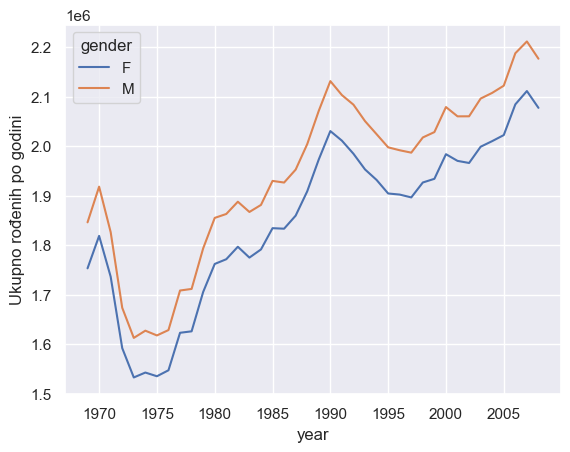

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
sns.set() # primena Seaborn stila
births.pivot_table('births', index='year', columns='gender', aggfunc='sum').plot()
plt.ylabel('Ukupno rođenih po godini')

Sa jednostavnom pivot tabelom i metodom `plot()`, možemo odmah videti godišnji trend rađanja po polu. Na oko, čini se da u poslednjih 50 godina rođenih muškaraca ima više od rođenih žena za oko 5%.

<br>

## Vežbanja

### ✍️ Zadatak 1.
Za početak pokrenite ispisane kodove, koji će da uvezu potrebnu bazu na kojoj ćete vršiti analizu. 

In [12]:
import pandas as pd
import numpy as np
from pandas import IndexSlice as idx 

In [14]:
df = pd.read_csv('Pandas_Podaci/data1.csv', index_col=['Dan'])
df.head(3)

,Vreme,Temperatura,Vetrovitost,Vlaznost_vazduha
Dan,,,,
Pon,Suncano,12.79,13,30
Uto,Suncano,19.67,28,96
Sre,Suncano,17.51,16,20


1. Prikažite dva ekvivalentna načina koja izbacuju temperaturu za petak
2. Izdvojite temperaturu za četvrtak i petak
3. Izdvojite temperaturu i vetrovitost za ponedeljak
4. Prikažite temperaturu i vetrovitost za utorak i nedelju
5. Izdvojite podatke za četvrtak i petak koji pokazuju temperaturu, vetrovitost i vlažnost vazduha
6. Izdvojite ponedeljak, sredu i petak i prikažite podatke za sve parametre
7. Kojim danima je vlažnost vazduha veća od 50?
8. Prikažite temperaturu i vetrovitost za dane kojima je vlažnost vazduha veća od 50 i vreme kišno?

#### Rešenje:

In [15]:
# 1.a);  Pass label to `loc`
df.loc['Pet', 'Temperatura']

np.float64(10.51)

In [16]:
# 1. b) The equivalent `iloc` statement should take row number 4 and column number 1
df.iloc[4, 1]

np.float64(10.51)

In [17]:
# 2. Multiple rows
df.loc[['Cet', 'Pet'], 'Temperatura']

Dan
Cet    14.44
Pet    10.51
Name: Temperatura, dtype: float64

In [18]:
# 3. Multiple columns
df.loc['Pon', ['Temperatura', 'Vetrovitost']]

Temperatura    12.79
Vetrovitost       13
Name: Pon, dtype: object

In [19]:
# 4.
rows = [1, 6]
cols = [1, 2]
df.iloc[rows, cols]

,Temperatura,Vetrovitost
Dan,,
Uto,19.67,28
Ned,17.50,20


In [20]:
# 5. Slicing column labels
rows=['Uto', 'Pet']
df.loc[rows, 'Temperatura':'Vlaznost_vazduha' ]

,Temperatura,Vetrovitost,Vlaznost_vazduha
Dan,,,
Uto,19.67,28,96
Pet,10.51,26,79


In [21]:
# 6. Slicing with step
df.loc['Pon':'Pet':2 , :]

,Vreme,Temperatura,Vetrovitost,Vlaznost_vazduha
Dan,,,,
Pon,Suncano,12.79,13,30
Sre,Suncano,17.51,16,20
Pet,Kisno,10.51,26,79


In [22]:
# 7. One condition
df.loc[df.Vlaznost_vazduha > 50, :]

,Vreme,Temperatura,Vetrovitost,Vlaznost_vazduha
Dan,,,,
Uto,Suncano,19.67,28,96
Pet,Kisno,10.51,26,79
Sub,Kisno,11.07,27,62


In [23]:
# 8. multiple conditions
df.loc[
    (df.Vlaznost_vazduha > 50) & (df.Vreme == 'Kisno'), 
    ['Temperatura','Vetrovitost'],
]

,Temperatura,Vetrovitost
Dan,,
Pet,10.51,26
Sub,11.07,27


### ✍️ Zadatak 2.
Kao i u prethodnom zahtevu, pokrenite kod za učitavanje baze podataka.

In [29]:
df = pd.read_csv('Pandas_podaci/vreme.csv', index_col=[0,1], header=[0,1] )
df.head(2)

Dan                                     \
                            Vreme Vetrovitost Maksimalna_temperatura   
Grad     Datum                                                         
Kembridz 7/1/2019           Kisno   SW 16 mph                     24   
         7/2/2019  Jaki pljuskovi    E 20 mph                     21   

                              Noc                                     
                            Vreme Vetrovitost Maksimalna_temperatura  
Grad     Datum                                                        
Kembridz 7/1/2019           Kisno   SW 16 mph                     17  
         7/2/2019  Jaki pljuskovi    E 20 mph                     16

1. Sortirajte po indeksima tabelu.
2. Prikažite podatke za London u toku dana.
3. Izdvojite podatke koji se odnose na dan, na sve gradove.
4. Prikažite sve dostupne podatke za Kembridž.
5. Izdvojite podatke koji se odnose na noć u Londonu 2.7.2019.
6. Prikažite vreme i vetrovitost koji se odnose na dan u gradu Kembridž.
7. Izdvojite sve parametre za noćne podatke u Oksfordu u periodu od 1.7.2019. do 3.7.2021.
8. Prikažite noćne podatke za sve gradove na datum 4.7.2019.
9. Izdvojite maksimalnu temperaturu i vreme, koji se odnose na dan u svim gradovima datume 1.7.2019.
10. Napravite novu kolonu “Razlika” koja će da pokazuje razliku između maksimalne temperature danju i maksimalne temperature noću.
11. Prikažite srednju vrednost razlike temperatura za svaki grad.

#### Rešenje:

In [30]:
#1. Tabela sortirana po indeksima
df = df.sort_index()
df

Dan                                     \
                                Vreme Vetrovitost Maksimalna_temperatura   
Grad     Datum                                                             
Kembridz 7/1/2019               Kisno   SW 16 mph                     24   
         7/2/2019      Jaki pljuskovi    E 20 mph                     21   
         7/3/2019      Jaki pljuskovi   SE 10 mph                     22   
         7/4/2019               Kisno    S 25 mph                     22   
London   7/1/2019               Kisno   SW 16 mph                     28   
         7/2/2019               Kisno   SW 16 mph                     29   
         7/3/2019        Jaki pljusak   SW 16 mph                     29   
         7/4/2019  Mestimicno oblacno   SW 16 mph                     31   
Oksford  7/1/2019               Kisno   SW 13 mph                     25   
         7/2/2019               Kisno   SW 16 mph                     26   
         7/3/2019      Jaki pljuskovi   SW 16 mph                     28   
         7/4/2019               Kisno   SW 14 mph                     25   

                                  Noc                                     
                                Vreme Vetrovitost Maksimalna_temperatura  
Grad     Datum                                                            
Kembridz 7/1/2019               Kisno   SW 16 mph                     17  
         7/2/2019      Jaki pljuskovi    E 20 mph                     16  
         7/3/2019      Jaki pljuskovi   SE 10 mph                     16  
         7/4/2019  Mestimicno oblacno    S 25 mph                     16  
London   7/1/2019               Kisno   SW 16 mph                     18  
         7/2/2019           Jaka kisa   SW 16 mph                     17  
         7/3/2019           Jaka kisa   SW 16 mph                     19  
         7/4/2019  Mestimicno oblacno   SW 16 mph                     23  
Oksford  7/1/2019               Kisno   SW 16 mph                     19  
         7/2/2019               Kisno   SW 16 mph                     19  
         7/3/2019      Jaki pljuskovi   SW 16 mph                     22  
         7/4/2019               Kisno   SW 16 mph                     21

In [31]:
#2. Podaci o Londonu za dan
df.loc['London' , 'Dan']

,Vreme,Vetrovitost,Maksimalna_temperatura
Datum,,,
7/1/2019,Kisno,SW 16 mph,28
7/2/2019,Kisno,SW 16 mph,29
7/3/2019,Jaki pljusak,SW 16 mph,29
7/4/2019,Mestimicno oblacno,SW 16 mph,31


In [32]:
#3. Podaci za sve gradove i dan ... To get all rows
df.loc[:, 'Dan']

Vreme Vetrovitost  Maksimalna_temperatura
Grad     Datum                                                           
Kembridz 7/1/2019               Kisno   SW 16 mph                      24
         7/2/2019      Jaki pljuskovi    E 20 mph                      21
         7/3/2019      Jaki pljuskovi   SE 10 mph                      22
         7/4/2019               Kisno    S 25 mph                      22
London   7/1/2019               Kisno   SW 16 mph                      28
         7/2/2019               Kisno   SW 16 mph                      29
         7/3/2019        Jaki pljusak   SW 16 mph                      29
         7/4/2019  Mestimicno oblacno   SW 16 mph                      31
Oksford  7/1/2019               Kisno   SW 13 mph                      25
         7/2/2019               Kisno   SW 16 mph                      26
         7/3/2019      Jaki pljuskovi   SW 16 mph                      28
         7/4/2019               Kisno   SW 14 mph                      25

In [33]:
#4. Dostupni podaci za Kemridž ... To get all columns
df.loc['Kembridz' , :]

Dan                                     \
                   Vreme Vetrovitost Maksimalna_temperatura   
Datum                                                         
7/1/2019           Kisno   SW 16 mph                     24   
7/2/2019  Jaki pljuskovi    E 20 mph                     21   
7/3/2019  Jaki pljuskovi   SE 10 mph                     22   
7/4/2019           Kisno    S 25 mph                     22   

                         Noc                                     
                       Vreme Vetrovitost Maksimalna_temperatura  
Datum                                                            
7/1/2019               Kisno   SW 16 mph                     17  
7/2/2019      Jaki pljuskovi    E 20 mph                     16  
7/3/2019      Jaki pljuskovi   SE 10 mph                     16  
7/4/2019  Mestimicno oblacno    S 25 mph                     16

In [34]:
#5. Podaci koji se odnose na noć u Londonu 2.7.2019
df.loc['London', 'Noc'].loc['7/2/2019']

Vreme                     Jaka kisa
Vetrovitost               SW 16 mph
Maksimalna_temperatura           17
Name: 7/2/2019, dtype: object

In [35]:
#6.  Vreme i vetrovitost koji se odnose na dan u gradu Kembridž ... Select multiple columns
df.loc['Kembridz', ('Dan', ['Vreme', 'Vetrovitost']) ]

Dan            
                   Vreme Vetrovitost
Datum                               
7/1/2019           Kisno   SW 16 mph
7/2/2019  Jaki pljuskovi    E 20 mph
7/3/2019  Jaki pljuskovi   SE 10 mph
7/4/2019           Kisno    S 25 mph

In [36]:
#7. Parametri za noćne podatke u Oksfordu u periodu od 1.7.2019. do 3.7.2021.
df.loc[('Oksford', '7/1/2019'):('Oksford','7/3/2019'),'Noc']

Vreme Vetrovitost  Maksimalna_temperatura
Grad    Datum                                                       
Oksford 7/1/2019           Kisno   SW 16 mph                      19
        7/2/2019           Kisno   SW 16 mph                      19
        7/3/2019  Jaki pljuskovi   SW 16 mph                      22

In [37]:
# 8.  Noćni podaci za sve gradove na datum 4.7.2019.
df.loc[idx[: , '7/4/2019'], 'Noc']

# Equivlant to 
# df.loc[ (slice(None) , '2019-07-04'), 'Night' ]

,,Vreme,Vetrovitost,Maksimalna_temperatura
Grad,Datum,,,
Kembridz,7/4/2019,Mestimicno oblacno,S 25 mph,16
London,7/4/2019,Mestimicno oblacno,SW 16 mph,23
Oksford,7/4/2019,Kisno,SW 16 mph,21


In [38]:
#9. Mksimalna temperatura i vreme, koji se odnose na dan u svim gradovima datume 1.7.2019.
rows = idx[: , '7/1/2019']
cols = idx['Dan' , ['Maksimalna_temperatura','Vreme']]

df.loc[rows, cols]

Dan       
                  Maksimalna_temperatura  Vreme
Grad     Datum                                 
Kembridz 7/1/2019                     24  Kisno
London   7/1/2019                     28  Kisno
Oksford  7/1/2019                     25  Kisno

In [41]:
#10. Nova kolona “Razlika” koja će da pokazuje razliku između maksimalne temperature danju i maksimalne temperature noću
prvi=df.loc[:, 'Dan'].loc[:,'Maksimalna_temperatura']
drugi=df.loc[:,'Noc'].loc[:,'Maksimalna_temperatura']
df['Razlika']=prvi-drugi
df

Dan                                     \
                                Vreme Vetrovitost Maksimalna_temperatura   
Grad     Datum                                                             
Kembridz 7/1/2019               Kisno   SW 16 mph                     24   
         7/2/2019      Jaki pljuskovi    E 20 mph                     21   
         7/3/2019      Jaki pljuskovi   SE 10 mph                     22   
         7/4/2019               Kisno    S 25 mph                     22   
London   7/1/2019               Kisno   SW 16 mph                     28   
         7/2/2019               Kisno   SW 16 mph                     29   
         7/3/2019        Jaki pljusak   SW 16 mph                     29   
         7/4/2019  Mestimicno oblacno   SW 16 mph                     31   
Oksford  7/1/2019               Kisno   SW 13 mph                     25   
         7/2/2019               Kisno   SW 16 mph                     26   
         7/3/2019      Jaki pljuskovi   SW 16 mph                     28   
         7/4/2019               Kisno   SW 14 mph                     25   

                                  Noc                                     \
                                Vreme Vetrovitost Maksimalna_temperatura   
Grad     Datum                                                             
Kembridz 7/1/2019               Kisno   SW 16 mph                     17   
         7/2/2019      Jaki pljuskovi    E 20 mph                     16   
         7/3/2019      Jaki pljuskovi   SE 10 mph                     16   
         7/4/2019  Mestimicno oblacno    S 25 mph                     16   
London   7/1/2019               Kisno   SW 16 mph                     18   
         7/2/2019           Jaka kisa   SW 16 mph                     17   
         7/3/2019           Jaka kisa   SW 16 mph                     19   
         7/4/2019  Mestimicno oblacno   SW 16 mph                     23   
Oksford  7/1/2019               Kisno   SW 16 mph                     19   
         7/2/2019               Kisno   SW 16 mph                     19   
         7/3/2019      Jaki pljuskovi   SW 16 mph                     22   
         7/4/2019               Kisno   SW 16 mph                     21   

                  Razlika  
                           
Grad     Datum             
Kembridz 7/1/2019       7  
         7/2/2019       5  
         7/3/2019       6  
         7/4/2019       6  
London   7/1/2019      10  
         7/2/2019      12  
         7/3/2019      10  
         7/4/2019       8  
Oksford  7/1/2019       6  
         7/2/2019       7  
         7/3/2019       6  
         7/4/2019       4

In [43]:
#11.  Srednja vrednost razlike temperatura za svaki grad
df['Razlika'].groupby(level='Grad').mean()

Grad
Kembridz     6.00
London      10.00
Oksford      5.75
Name: Razlika, dtype: float64

<br>

## Zadaci i problemi

:::{admonition} Zadatak 1.
:class: tip 

Imate restoran brze hrane i uradili ste neko istraživanje tržišta u pokušaju da bolje razumete svoje klijente. U slučajnom uzorku kupaca, imate prihod, pol i broj dana u nedelji kada osoba ide na brzu hranu. Koristite ove informacije da odredite kako pol i prihod utiču na učestalost kojom osoba izlazi da jede brzu hranu. Podaci se nalaze u datoteci `Pandas_Podaci/Mcdonalds.xlsx`
:::

:::{admonition} Zadatak 2.
:class: tip 

Preduzeće `EcoPlast` prodaje svoje proizvode (boce i posude) u nekoliko regiona tokom godine. Podaci o prodaji sačuvani su u datoteci `Pandas_Podaci/EcoPlast.csv` koja sadrži sledeće kolone:

-
    - `Region` – naziv regiona (npr. "Sever", "Jug", "Istok", "Zapad")
    - `Proizvod` – naziv proizvoda (npr. "Boca", "Posuda")
    - `Mesec` – mesec prodaje (npr. "Januar", "Februar", ...)
    - `Prihod` – ostvareni prihod u dinarima
  

1. Napraviti pivot tabelu koja prikazuje ukupan prihod po regionima i mesecima kao i ukupne vrednosti po redovima i kolonama.
3. Prikaži rezultate pivot tabele pomoću bar grafikona.
:::

:::{admonition} Zadatak 3.
:class: tip 

Datoteka `Pandas_Podaci/Makeupdb.xlsx` sadrži informacije o prodaji proizvoda za šminkanje. Za svaku transakciju, imamo sledeće informacije:
  Ime prodavca; Datum prodaje; Naziv proizvoda; Broj prodatih jedinica; Prihod od transakcije; Lokacija.
  
Napravite pivot tabele da biste sastavili sledeće informacije:
- Koji prodavac je ostvario najveći ukupan prihod od prodaje u 2004 godini?
- Za kojim proizvodom je najveća tražnja na lokaciji east u 2006 godini?
:::

:::{admonition} Zadatak 4.
:class: tip 

U eksel datoteci `Pandas_Podaci/izvoz_podaci.xlsx` nalaze se kvartalni podaci o izvozu (u milionima evra) po sektorima. Zahtevi:

1. Prikaži ukupan izvoz po godinama i sektorima
2. Izračunaj prosečan izvoz po sektorima (bez obzira na godinu).  
3. Nađi kvartal u kome je Industrija imala najveći izvoz u 2023. godini.
:::

:::{admonition} Zadatak 5.
:class: tip 

Podaci u rečniku:
```python data = {
    "Tačka": ["A", "B", "C", "D", "E", "F", "G", "H", "J", "I"],
    "X": [9, 8, 7, 6, 5, 3, 2, 1, 4, 9],
    "Y": [1, 2, 3, 6, 5, 7, 8, 9, 4, 9]}
```
predstavljaju dve numeričke promenljive $X$ i $Y$ (po jedna u svakoj koloni). Svaki red predstavlja jednu tačku $(x_i, y_i)$.
- Idealno loša tačka je ona koja ima najmanje vrednosti obe promenljive:  $(x_{\min}, y_{\min})$
- Idealno dobra tačka je ona koja ima najveće vrednosti obe promenljive: $(x_{\max}, y_{\max})$

1. Za svaku tačku $(x_i, y_i)$ izračunaj Euklidsko rastojanje od idealno loše tačke:
   $$  d_i^{-} = \sqrt{(x_i - x_{\min})^2 + (y_i - y_{\min})^2} $$
   Tačke koje su dalje od idealno loše tačke (imaju veće vrednosti $d_i^{-})$ smatraju se boljima.
   Na osnovu dobijenih vrednosti formiraj rang-listu (1 = najbolja tačka).

2. Za svaku tačku $(x_i, y_i)$ izračunaj Euklidsko rastojanje od idealno dobre tačke:
   $$ d_i^{+} = \sqrt{(x_{\max} - x_i)^2 + (y_{\max} - y_i)^2} $$
   Tačke koje su bliže idealno dobroj tački (imaju manje vrednosti $d_i^{+})$ smatraju se boljima.
   Na osnovu toga formiraj drugu rang-listu (1 = najbolja tačka).

3. Da li se redosled tačaka poklapa u oba slučaja?
:::

<br>

## Studije slučaja

### 🧩 Restorani

U datoteci `Pandas_Podaci/Restaurant.xlsx` nalaze se podaci o restoranima. Datoteka sa podacima ima sledeće kolone (polja) : `Quality Rating`, `Meal Price ($)`	i `Wait Time (min)`.

- Grupisati restorane na osnovu kvaliteta i vremena čekanja.
- Napraviti tabelu koja će pokazati kako kvalitet usluge i cena mesa utiče na vreme čekanja.
- Rezultate u poslednjoj tabeli vizuelizujte.
- Kakve zaklučke možete izvesti na osnovu prethodnih informacija?

## Literatura

```{bibliography}
:style: unsrt
:filter: docname in docnames